<a href="https://colab.research.google.com/github/aykahsay/paris-ozone-time-series-forecasting/blob/main/paris-ozone-time-series-forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Time Series Analysis and Forecasting of Ground-Level Ozone (O₃) Concentrations in Paris Using Machine Learning**

## 1. Data Collection (OpenAQ API)

The hourly ozone (O₃) measurements used in this project were collected from the [OpenAQ v3 API](https://docs.openaq.org/) for a monitoring sensor in Paris. The cells below were originally run in Google Colab (using a Colab secret for the API key) to page through the sensor's measurement history and assemble the raw hourly series, which was then saved as `ozone_df.csv`.

**These cells require a Colab environment and an `OPENAQ_API_KEY` secret to re-run.** They are kept here for provenance/reproducibility of the data collection step. From Section 2 onward, the notebook only reads `ozone_df.csv`, which is included in this repository, so the rest of the analysis runs anywhere without API access.

In [10]:
from google.colab import userdata

API_KEY = userdata.get("OPENAQ_API_KEY")

In [11]:
import requests
from google.colab import userdata

API_KEY = userdata.get("OPENAQ_API_KEY")

headers = {
    "X-API-Key": API_KEY
}

url = "https://api.openaq.org/v3/locations?city=Los Angeles"

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.json())

200
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 100, 'found': '>100'}, 'results': [{'id': 3, 'name': 'NMA - Nima', 'locality': None, 'timezone': 'Africa/Accra', 'country': {'id': 152, 'code': 'GH', 'name': 'Ghana'}, 'owner': {'id': 4, 'name': 'Unknown Governmental Organization'}, 'provider': {'id': 209, 'name': 'Dr. Raphael E. Arku and Colleagues'}, 'isMobile': False, 'isMonitor': True, 'instruments': [{'id': 2, 'name': 'Government Monitor'}], 'sensors': [{'id': 6, 'name': 'pm10 µg/m³', 'parameter': {'id': 1, 'name': 'pm10', 'units': 'µg/m³', 'displayName': 'PM10'}}, {'id': 5, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}}], 'coordinates': {'latitude': 5.58389, 'longitude': -0.19968}, 'licenses': None, 'bounds': [-0.19968, 5.58389, -0.19968, 5.58389], 'distance': None, 'datetimeFirst': None, 'datetimeLast': None}, {'id': 4, 'name': 'NMT - Nima', 'locality': None, 'timezone': 'Africa/Accra', 'country': {'id

In [12]:
import requests
from google.colab import userdata

API_KEY = userdata.get("OPENAQ_API_KEY")

headers = {
    "X-API-Key": API_KEY
}

location_id = 4124

url = f"https://api.openaq.org/v3/locations/{location_id}"

response = requests.get(url, headers=headers)

response.json()

{'meta': {'name': 'openaq-api',
  'website': '/',
  'page': 1,
  'limit': 100,
  'found': 1},
 'results': [{'id': 4124,
   'name': 'PARIS 13eme',
   'locality': 'PARIS 13E ARRONDISSEMENT',
   'timezone': 'Europe/Paris',
   'country': {'id': 22, 'code': 'FR', 'name': 'France'},
   'owner': {'id': 4, 'name': 'Unknown Governmental Organization'},
   'provider': {'id': 70, 'name': 'EEA'},
   'isMobile': False,
   'isMonitor': True,
   'instruments': [{'id': 2, 'name': 'Government Monitor'}],
   'sensors': [{'id': 4274755,
     'name': 'no µg/m³',
     'parameter': {'id': 19843,
      'name': 'no',
      'units': 'µg/m³',
      'displayName': 'NO mass'}},
    {'id': 9779,
     'name': 'no2 µg/m³',
     'parameter': {'id': 5,
      'name': 'no2',
      'units': 'µg/m³',
      'displayName': 'NO₂ mass'}},
    {'id': 9782,
     'name': 'o3 µg/m³',
     'parameter': {'id': 3,
      'name': 'o3',
      'units': 'µg/m³',
      'displayName': 'O₃ mass'}}],
   'coordinates': {'latitude': 48.8286100

In [13]:
import requests
import pandas as pd
from google.colab import userdata

API_KEY = userdata.get("OPENAQ_API_KEY")

headers = {
    "X-API-Key": API_KEY
}

sensor_id = 9782

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

params = {
    "limit": 1000,
    "page": 1
}

response = requests.get(url, headers=headers, params=params)

data = response.json()

print(data["meta"])

{'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 1000, 'found': '>1000'}


In [17]:
import requests
import pandas as pd
from google.colab import userdata

API_KEY = userdata.get("OPENAQ_API_KEY")

headers = {
    "X-API-Key": API_KEY
}

sensor_id = 9782  # Paris O3 sensor
url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

all_results = []

for page in range(1, 16):  # Pages 1 to 15
    params = {
        "limit": 1000,
        "page": page
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()

    results = response.json()["results"]

    if not results:
        break

    all_results.extend(results)

    print(f"Page {page}: {len(results)} records")

df = pd.DataFrame(all_results)

print(f"\nTotal records: {len(df)}")

Page 1: 1000 records
Page 2: 1000 records
Page 3: 1000 records
Page 4: 1000 records
Page 5: 1000 records
Page 6: 1000 records
Page 7: 1000 records
Page 8: 1000 records
Page 9: 1000 records
Page 10: 1000 records
Page 11: 1000 records
Page 12: 1000 records
Page 13: 1000 records
Page 14: 1000 records
Page 15: 1000 records

Total records: 15000


In [18]:
print(df.head)

<bound method NDFrame.head of        value             flagInfo  \
0      27.50  {'hasFlags': False}   
1      56.25  {'hasFlags': False}   
2      37.25  {'hasFlags': False}   
3      31.75  {'hasFlags': False}   
4      38.25  {'hasFlags': False}   
...      ...                  ...   
14995  81.90  {'hasFlags': False}   
14996  62.20  {'hasFlags': False}   
14997  56.70  {'hasFlags': False}   
14998  54.50  {'hasFlags': False}   
14999  49.10  {'hasFlags': False}   

                                               parameter  \
0      {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
1      {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
2      {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
3      {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
4      {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
...                                                  ...   
14995  {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
14996  {'id': 3, 'name': 'o3', 'units': 'µg/m

In [19]:
print(df.head())

   value             flagInfo  \
0  27.50  {'hasFlags': False}   
1  56.25  {'hasFlags': False}   
2  37.25  {'hasFlags': False}   
3  31.75  {'hasFlags': False}   
4  38.25  {'hasFlags': False}   

                                           parameter  \
0  {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
1  {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
2  {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
3  {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   
4  {'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...   

                                              period coordinates summary  \
0  {'label': 'raw', 'interval': '01:00:00', 'date...        None    None   
1  {'label': 'raw', 'interval': '01:00:00', 'date...        None    None   
2  {'label': 'raw', 'interval': '01:00:00', 'date...        None    None   
3  {'label': 'raw', 'interval': '01:00:00', 'date...        None    None   
4  {'label': 'raw', 'interval': '01:00:00', 'date...        None    None   

       

In [20]:
df["period"].iloc[0]

{'label': 'raw',
 'interval': '01:00:00',
 'datetimeFrom': {'utc': '2016-11-21T11:00:00Z',
  'local': '2016-11-21T12:00:00+01:00'},
 'datetimeTo': {'utc': '2016-11-21T12:00:00Z',
  'local': '2016-11-21T13:00:00+01:00'}}

In [22]:
df["Date"] = df["period"].apply(lambda x: x["datetimeFrom"]["utc"])
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,value,flagInfo,parameter,period,coordinates,summary,coverage,Date
0,27.50,{'hasFlags': False},"{'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...","{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",2016-11-21 11:00:00+00:00
1,56.25,{'hasFlags': False},"{'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...","{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",2016-11-21 13:00:00+00:00
2,37.25,{'hasFlags': False},"{'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...","{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",2016-11-21 15:00:00+00:00
3,31.75,{'hasFlags': False},"{'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...","{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",2016-11-21 17:00:00+00:00
4,38.25,{'hasFlags': False},"{'id': 3, 'name': 'o3', 'units': 'µg/m³', 'dis...","{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",2016-11-21 19:00:00+00:00


In [23]:
ozone_df = df[["Date", "value"]].copy()

ozone_df.rename(columns={"value": "Ozone"}, inplace=True)

ozone_df.head()

,Date,Ozone
0,2016-11-21 11:00:00+00:00,27.50
1,2016-11-21 13:00:00+00:00,56.25
2,2016-11-21 15:00:00+00:00,37.25
3,2016-11-21 17:00:00+00:00,31.75
4,2016-11-21 19:00:00+00:00,38.25


## 2. Load Data

From here on the analysis is fully reproducible without API access — we load the previously collected data directly from `ozone_df.csv`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

plt.rcParams["figure.figsize"] = (12, 4.5)

ozone_df = pd.read_csv("ozone_df.csv", parse_dates=["Date"])
ozone_df = ozone_df.sort_values("Date").drop_duplicates(subset="Date").set_index("Date")

print(f"Hourly observations: {len(ozone_df):,}")
print(f"Date range: {ozone_df.index.min()} -> {ozone_df.index.max()}")
ozone_df.head()

Hourly observations: 15,000
Date range: 2016-11-21 11:00:00+00:00 -> 2019-08-30 22:00:00+00:00


,Ozone
Date,
2016-11-21 11:00:00+00:00,27.50
2016-11-21 13:00:00+00:00,56.25
2016-11-21 15:00:00+00:00,37.25
2016-11-21 17:00:00+00:00,31.75
2016-11-21 19:00:00+00:00,38.25


## 3. Exploratory Data Analysis

count    15000.000000
mean        48.821539
std         30.918845
min          0.000000
25%         26.000000
50%         47.750000
75%         67.750000
max        195.500000
Name: Ozone, dtype: float64


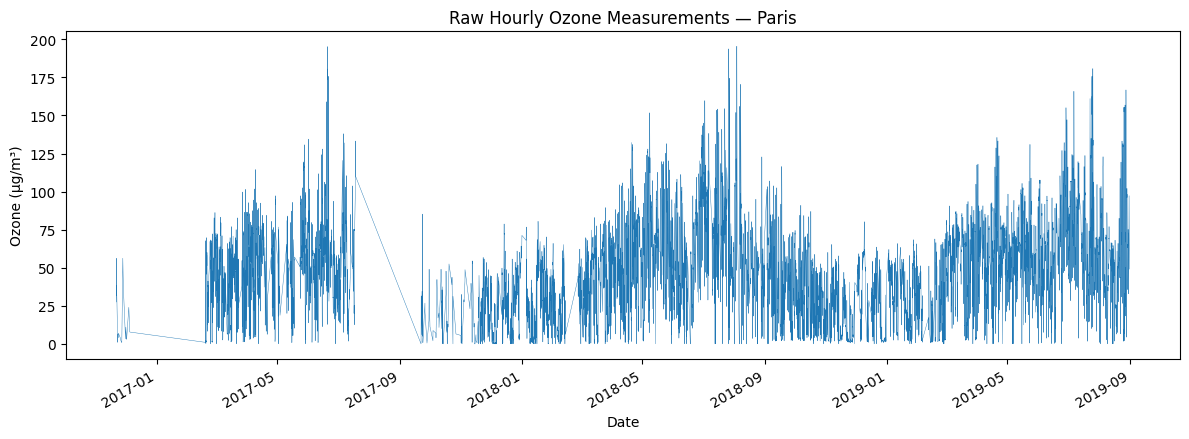

In [2]:
print(ozone_df["Ozone"].describe())

fig, ax = plt.subplots()
ozone_df["Ozone"].plot(ax=ax, lw=0.3, color="tab:blue")
ax.set_title("Raw Hourly Ozone Measurements — Paris")
ax.set_ylabel("Ozone (µg/m³)")
plt.tight_layout()
plt.show()

Ozone concentrations range from 0 to roughly 195 µg/m³, with a mean around 49 µg/m³. The raw sensor readings are also **irregularly spaced** — measurements are not recorded on a fixed schedule — so before any time-series modeling we resample onto a regular daily grid by averaging same-day observations.

## 4. Handling Missing Data & Resampling

We resample to a daily mean and inspect how much of the resulting calendar is missing.

In [3]:
daily_raw = ozone_df["Ozone"].resample("D").mean().asfreq("D")

# 2016 contributes only 11 partial days at the very start of the record; drop it and start
# the series from the first full calendar year.
daily_raw = daily_raw.loc["2017-01-01":]

print(f"Daily calendar days: {len(daily_raw)}")
print(f"Missing days: {daily_raw.isna().sum()} ({daily_raw.isna().mean():.1%})")

is_null = daily_raw.isna()
gap_id = (is_null != is_null.shift()).cumsum()
gap_lengths = daily_raw[is_null].groupby(gap_id[is_null]).size().sort_values(ascending=False)
print("\nLongest gaps (consecutive missing days):")
print(gap_lengths.head(10))

Daily calendar days: 972
Missing days: 217 (22.3%)

Longest gaps (consecutive missing days):
Ozone
23     65
1      48
63     11
13      5
103     5
17      5
57      4
43      4
47      4
9       3
Name: Ozone, dtype: int64


Most gaps are only 1–2 days long and can safely be bridged with interpolation. A handful of much longer gaps (up to 75 days) reflect real sensor outages. We time-interpolate all gaps so the series is complete for decomposition and modeling, but we explicitly **flag days that fall inside long gaps (>14 days)** — values there are synthetic (linearly interpolated across the outage) and any patterns landing on them should be discounted rather than read as real signal.

Remaining missing after interpolation: 0
Days inside long (>14d) interpolated gaps: 113 (11.6%)


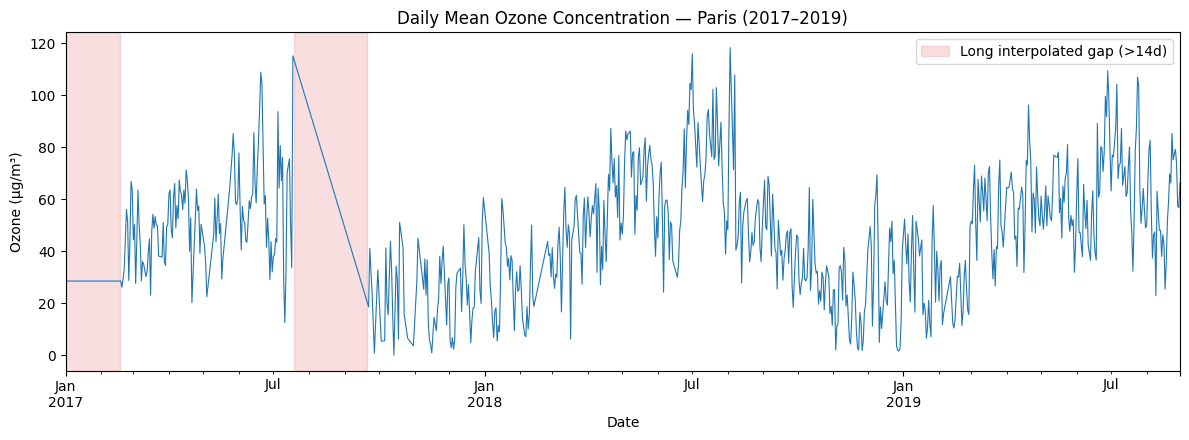

In [4]:
long_gap_mask = pd.Series(False, index=daily_raw.index)
gap_id2 = (daily_raw.isna() != daily_raw.isna().shift()).cumsum()
for _, grp in daily_raw[daily_raw.isna()].groupby(gap_id2[daily_raw.isna()]):
    if len(grp) > 14:
        long_gap_mask.loc[grp.index] = True

daily = daily_raw.interpolate(method="time").ffill().bfill()
print(f"Remaining missing after interpolation: {daily.isna().sum()}")
print(f"Days inside long (>14d) interpolated gaps: {long_gap_mask.sum()} ({long_gap_mask.mean():.1%})")

fig, ax = plt.subplots()
daily.plot(ax=ax, color="tab:blue", lw=0.8)
for _, grp in daily[long_gap_mask].groupby((~long_gap_mask).cumsum()[long_gap_mask]):
    ax.axvspan(grp.index.min(), grp.index.max(), color="tab:red", alpha=0.15)
ax.set_title("Daily Mean Ozone Concentration — Paris (2017–2019)")
ax.set_ylabel("Ozone (µg/m³)")
ax.legend(handles=[Patch(color="tab:red", alpha=0.15, label="Long interpolated gap (>14d)")])
plt.tight_layout()
plt.show()

## 5. Seasonal-Trend Decomposition (STL)

We decompose the gap-filled daily series into trend, seasonal (annual, period = 365 days), and residual components using STL (Seasonal-Trend decomposition using LOESS).

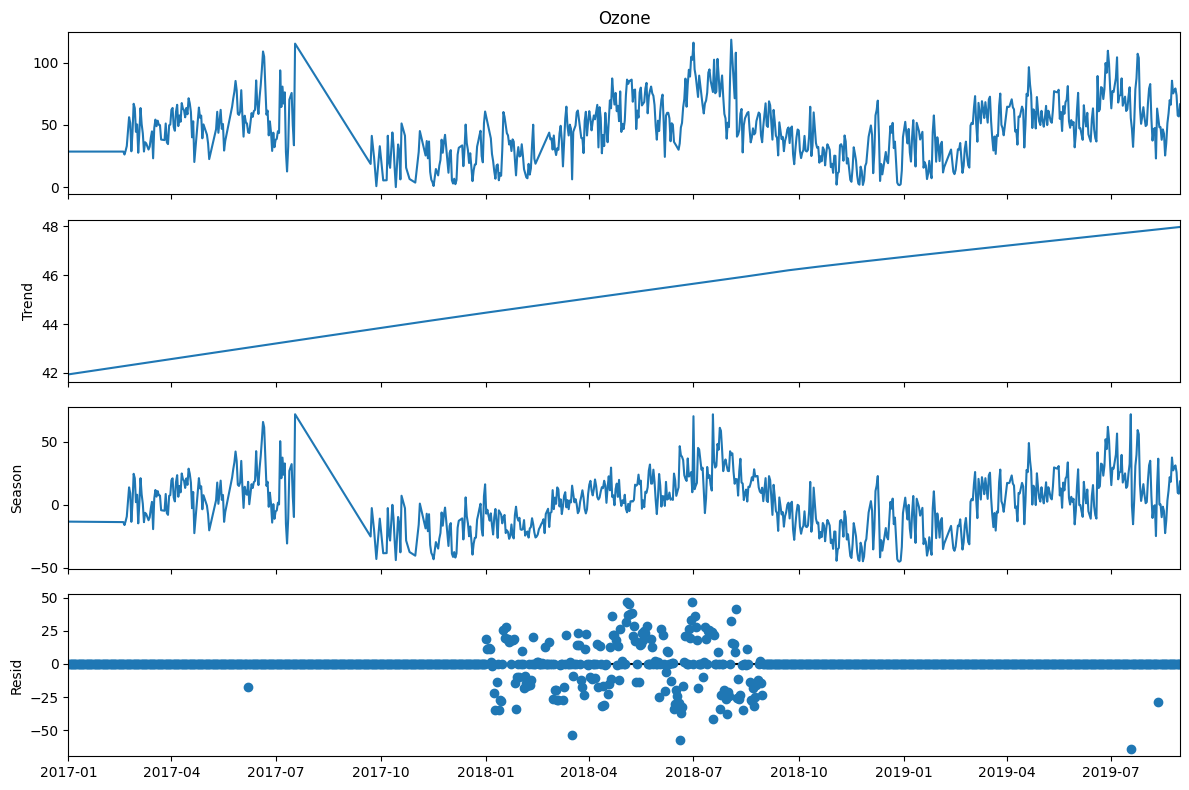

In [5]:
stl_result = STL(daily, period=365, robust=True).fit()

fig = stl_result.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

The **trend** component shows a mild, roughly linear increase over the ~2.7-year observation window. The **seasonal** component confirms the expected annual cycle for ground-level ozone: concentrations peak in the warmer months (spring/summer), when stronger sunlight drives photochemical production, and dip in winter. The **residual** component still carries substantial day-to-day variability (largely weather-driven — temperature, wind, precipitation — none of which are in this dataset), which is the main limiting factor for daily-level forecast accuracy explored later in this notebook.

## 6. Stationarity Testing

We test both the level series and its first difference with the Augmented Dickey-Fuller (ADF) test (null hypothesis: unit root / non-stationary) and the KPSS test (null hypothesis: stationary), since the two tests have complementary blind spots.

In [6]:
def stationarity_report(series, label):
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"{label:>10s} | ADF stat={adf_stat:7.3f}  p={adf_p:.4f}  | KPSS stat={kpss_stat:6.3f}  p={kpss_p:.4f}")

stationarity_report(daily, "Level")
stationarity_report(daily.diff(), "1st diff")

     Level | ADF stat= -3.188  p=0.0207  | KPSS stat= 0.260  p=0.1000
  1st diff | ADF stat=-13.927  p=0.0000  | KPSS stat= 0.035  p=0.1000


C:\Users\Admin\AppData\Local\Temp\ipykernel_16756\3361919001.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\Admin\AppData\Local\Temp\ipykernel_16756\3361919001.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")


At the level, the ADF test rejects the unit-root null (p < 0.05) and the KPSS test fails to reject its stationarity null (p > 0.05) — the two tests **agree that the series is already stationary**, consistent with STL's near-flat trend. First-differencing pushes both tests even further toward stationarity. We let AIC-based order selection (next section) decide whether differencing is still worth including in the forecasting model.

## 7. ACF / PACF Analysis

Autocorrelation and partial autocorrelation of the differenced series help identify candidate ARIMA orders.

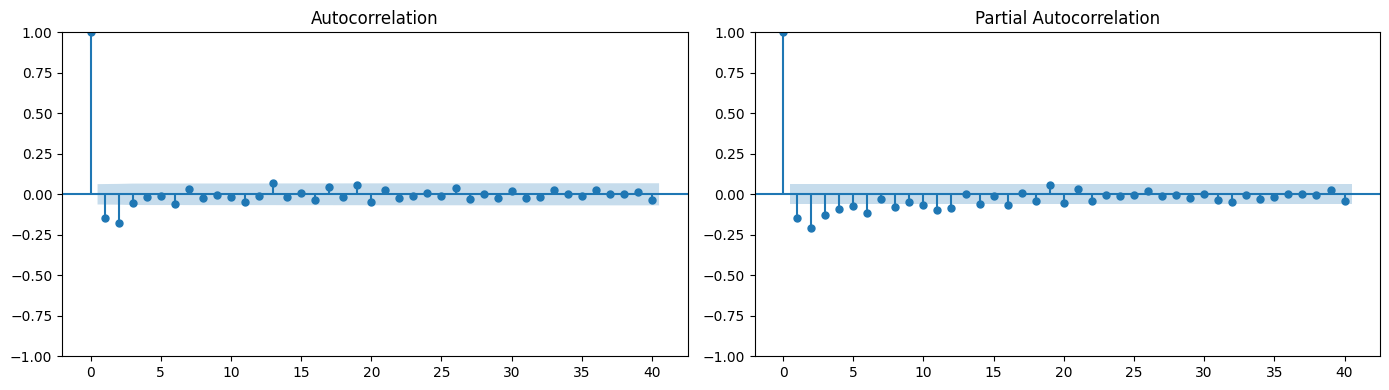

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily.diff().dropna(), lags=40, ax=axes[0])
plot_pacf(daily.diff().dropna(), lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

Both ACF and PACF show significant spikes mainly at lags 1–2, then cut off sharply into the confidence band, suggesting a low-order ARMA structure (p, q ≤ 2) is sufficient — which we confirm with an AIC grid search below.

## 8. Train / Validation / Test Split

We split the series chronologically into three parts, in proportions 60% / 20% / 20%:

- **Train** — used to fit each model.
- **Validation** — used to select each model's hyperparameters (SARIMA order, XGBoost's number of boosting rounds) by out-of-sample forecast accuracy, never seen during fitting.
- **Test** — used exactly once, at the end, for a final unbiased evaluation. After hyperparameters are locked in on the validation set, each model is refit on train + validation combined so it can use as much history as possible before forecasting the test period.

Every model below reports its own **prediction** and **evaluation** on both the validation and test sets, so results are directly comparable model-by-model.

In [8]:
n = len(daily)
n_test = int(n * 0.2)
n_val = int(n * 0.2)

train = daily.iloc[: n - n_val - n_test]
val = daily.iloc[n - n_val - n_test : n - n_test]
test = daily.iloc[n - n_test :]
trainval = pd.concat([train, val])

print(f"Train:      {len(train)} days, {train.index.min().date()} -> {train.index.max().date()}")
print(f"Validation: {len(val)} days, {val.index.min().date()} -> {val.index.max().date()}")
print(f"Test:       {len(test)} days, {test.index.min().date()} -> {test.index.max().date()}")

def forecast_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape}

def show_metrics(name):
    return pd.DataFrame(
        {"Validation": val_results[name], "Test": test_results[name]}
    ).T

val_results, test_results = {}, {}
val_preds, test_preds = {}, {}

Train:      584 days, 2017-01-01 -> 2018-08-07
Validation: 194 days, 2018-08-08 -> 2019-02-17
Test:       194 days, 2019-02-18 -> 2019-08-30


## 9. Baseline Models

Two simple baselines: a **naive** forecast (repeat the last observed value) and a **seasonal naive** forecast (repeat the value from 7 days earlier). Every subsequent model needs to clearly beat these on both validation and test.

In [9]:
def naive_forecast(history, horizon):
    return pd.Series(history.iloc[-1], index=horizon.index)

def seasonal_naive_forecast(history, horizon, season=7):
    return pd.Series(np.resize(history.iloc[-season:].values, len(horizon)), index=horizon.index)

val_preds["Naive"] = naive_forecast(train, val)
test_preds["Naive"] = naive_forecast(trainval, test)
val_preds["Seasonal Naive (7d)"] = seasonal_naive_forecast(train, val)
test_preds["Seasonal Naive (7d)"] = seasonal_naive_forecast(trainval, test)

for name in ["Naive", "Seasonal Naive (7d)"]:
    val_results[name] = forecast_metrics(val, val_preds[name])
    test_results[name] = forecast_metrics(test, test_preds[name])

pd.concat({name: show_metrics(name) for name in ["Naive", "Seasonal Naive (7d)"]})

MAE       RMSE    MAPE (%)
Naive               Validation  75.184906  76.947864  531.607297
                    Test        29.322367  33.624209   46.624593
Seasonal Naive (7d) Validation  56.760938  62.761230  436.324826
                    Test        38.929172  43.328137   62.632491

## 10. SARIMA Model

A full seasonal ARIMA with an annual seasonal period (`s = 365`) is not computationally tractable with a state-space SARIMAX implementation. Instead we model the **weekly** seasonal pattern directly in the seasonal ARIMA term (`s = 7`) and capture the **annual** cycle with a pair of Fourier terms (sine/cosine at the annual frequency) supplied as exogenous regressors.

**Model selection:** we grid-search small (p, d, q) x (P, Q) combinations, fit each on the training set only, forecast the validation horizon, and keep the combination with the lowest validation RMSE — i.e. we select the order by genuine out-of-sample forecast accuracy rather than in-sample AIC.

In [10]:
def fourier_terms(index, period=365.25, K=2):
    t = np.arange(len(index))
    terms = {}
    for k in range(1, K + 1):
        terms[f"sin{k}"] = np.sin(2 * np.pi * k * t / period)
        terms[f"cos{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(terms, index=index)

exog_full = fourier_terms(daily.index)
exog_train, exog_val, exog_test = exog_full.loc[train.index], exog_full.loc[val.index], exog_full.loc[test.index]
exog_trainval = pd.concat([exog_train, exog_val])

# maxiter is raised from the statsmodels default (50) to 200: with the default, several
# candidate orders stop before the optimizer actually converges (ConvergenceWarning), which
# would silently bias order selection towards models that merely fit fast rather than well.
best_rmse, best_order, best_seasonal = np.inf, None, None
for p in range(3):
    for d in [0, 1]:
        for q in range(3):
            for P in range(2):
                for Q in range(2):
                    try:
                        fit = SARIMAX(
                            train, order=(p, d, q), seasonal_order=(P, 0, Q, 7),
                            exog=exog_train, enforce_stationarity=False, enforce_invertibility=False,
                        ).fit(disp=False, maxiter=200)
                        pred = fit.get_forecast(steps=len(val), exog=exog_val).predicted_mean
                        rmse = np.sqrt(mean_squared_error(val.values, pred.values))
                        if rmse < best_rmse:
                            best_rmse = rmse
                            best_order, best_seasonal = (p, d, q), (P, 0, Q, 7)
                    except Exception:
                        continue

print(f"Best order: {best_order}  seasonal_order: {best_seasonal}  validation RMSE: {best_rmse:.2f}")

Best order: (0, 0, 0)  seasonal_order: (1, 0, 1, 7)  validation RMSE: 15.86


**Prediction (validation):** fit on the training set only, forecast the validation horizon.

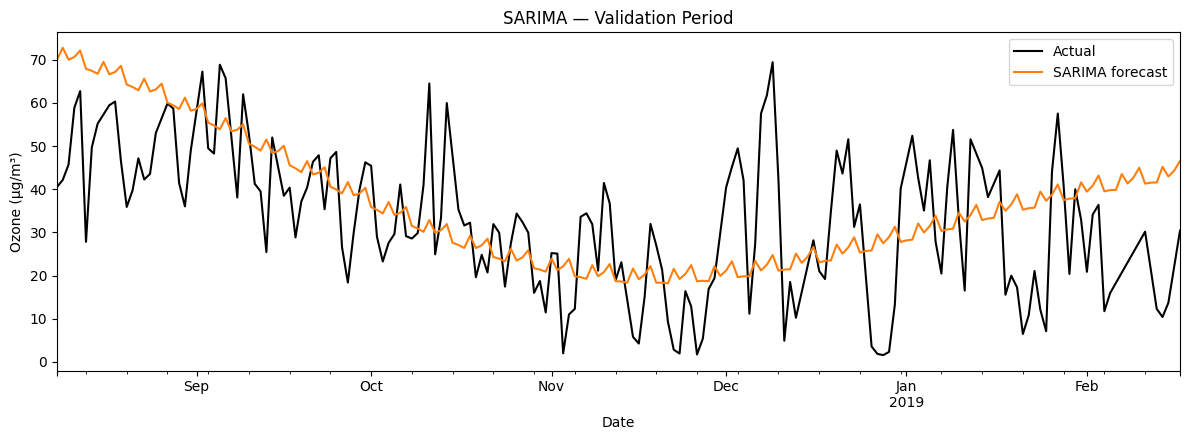

In [11]:
sarima_val_fit = SARIMAX(
    train, order=best_order, seasonal_order=best_seasonal,
    exog=exog_train, enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=200)

sarima_val_pred = sarima_val_fit.get_forecast(steps=len(val), exog=exog_val).predicted_mean
sarima_val_pred.index = val.index
val_preds["SARIMA"] = sarima_val_pred
val_results["SARIMA"] = forecast_metrics(val, sarima_val_pred)

fig, ax = plt.subplots()
val.plot(ax=ax, label="Actual", color="black")
sarima_val_pred.plot(ax=ax, label="SARIMA forecast", color="tab:orange")
ax.set_title("SARIMA — Validation Period")
ax.set_ylabel("Ozone (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

**Prediction (test):** with the order fixed by validation, refit on train + validation combined and forecast the held-out test period exactly once.

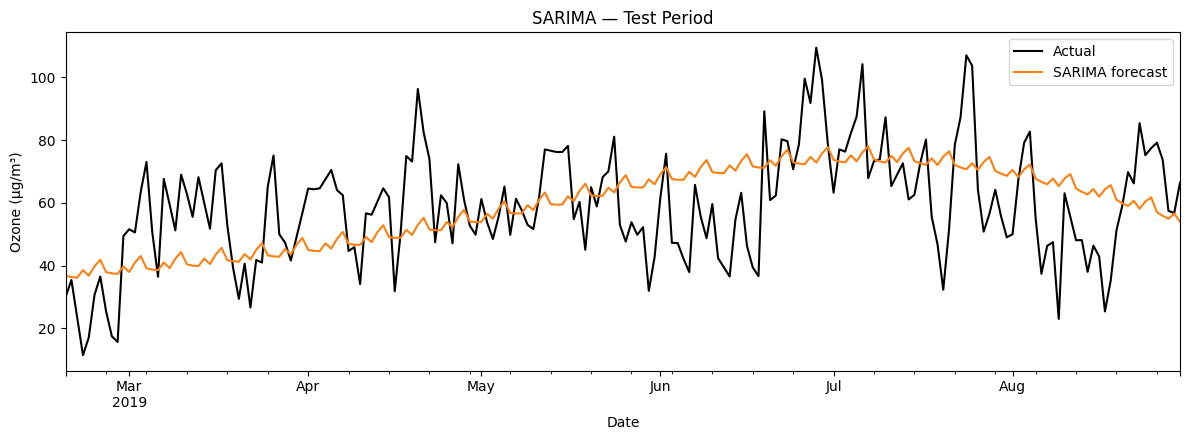

In [12]:
sarima_final_fit = SARIMAX(
    trainval, order=best_order, seasonal_order=best_seasonal,
    exog=exog_trainval, enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=200)

sarima_test_pred = sarima_final_fit.get_forecast(steps=len(test), exog=exog_test).predicted_mean
sarima_test_pred.index = test.index
test_preds["SARIMA"] = sarima_test_pred
test_results["SARIMA"] = forecast_metrics(test, sarima_test_pred)

fig, ax = plt.subplots()
test.plot(ax=ax, label="Actual", color="black")
sarima_test_pred.plot(ax=ax, label="SARIMA forecast", color="tab:orange")
ax.set_title("SARIMA — Test Period")
ax.set_ylabel("Ozone (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

**Evaluation (SARIMA):**

In [13]:
show_metrics("SARIMA")

,MAE,RMSE,MAPE (%)
Validation,12.911921,15.859842,95.585307
Test,14.378972,17.565032,29.465468


## 11. Machine Learning Model (XGBoost)

As an alternative to the classical SARIMA approach, we train a gradient-boosted tree model on engineered features: multiple lags, rolling statistics, calendar variables (day-of-week, month), and the same Fourier terms used above for annual seasonality.

In [14]:
def build_features(series, K=2, period=365.25):
    feat = pd.DataFrame({"y": series})
    for lag in [1, 2, 3, 7, 14, 21]:
        feat[f"lag{lag}"] = series.shift(lag)
    feat["roll_mean_7"] = series.shift(1).rolling(7).mean()
    feat["roll_std_7"] = series.shift(1).rolling(7).std()
    feat["roll_mean_14"] = series.shift(1).rolling(14).mean()
    feat["dow"] = series.index.dayofweek
    feat["month"] = series.index.month
    t = np.arange(len(series))
    for k in range(1, K + 1):
        feat[f"sin{k}"] = np.sin(2 * np.pi * k * t / period)
        feat[f"cos{k}"] = np.cos(2 * np.pi * k * t / period)
    return feat

feature_cols = [c for c in build_features(daily).columns if c != "y"]
full_feat = build_features(daily).dropna()

def split_xy(index):
    rows = full_feat.loc[full_feat.index.isin(index)]
    return rows[feature_cols], rows["y"]

X_train, y_train = split_xy(train.index)
X_val, y_val = split_xy(val.index)

**Model selection:** we train with early stopping against the validation set to choose the number of boosting rounds — analogous to how SARIMA's order was chosen on validation RMSE above.

In [15]:
xgb_val_model = XGBRegressor(
    n_estimators=1000, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=30, eval_metric="rmse",
)
xgb_val_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

best_iteration = xgb_val_model.best_iteration
print(f"Selected number of boosting rounds: {best_iteration}")

def recursive_forecast(model, history, horizon_index):
    history = history.copy()
    preds = []
    for date in horizon_index:
        extended = pd.concat([history, pd.Series([np.nan], index=[date])])
        x_row = build_features(extended).loc[[date], feature_cols]
        pred = model.predict(x_row)[0]
        preds.append(pred)
        history.loc[date] = pred
    return pd.Series(preds, index=horizon_index)

Selected number of boosting rounds: 88


**Prediction (validation):** forecast the validation horizon recursively, using only training data as history (each predicted value is fed back in to build the next step's lag features, so the model never sees true validation values).

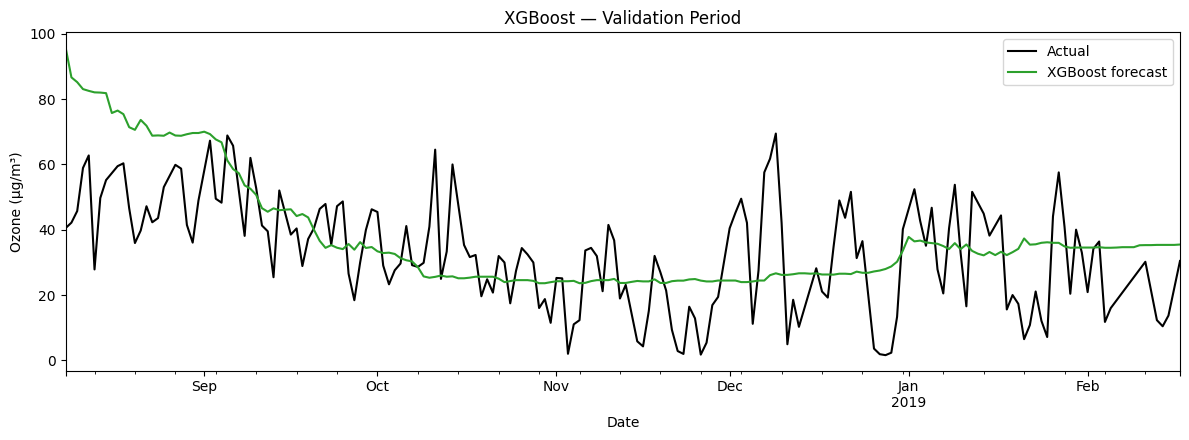

In [16]:
xgb_val_pred = recursive_forecast(xgb_val_model, train, val.index)
val_preds["XGBoost"] = xgb_val_pred
val_results["XGBoost"] = forecast_metrics(val, xgb_val_pred)

fig, ax = plt.subplots()
val.plot(ax=ax, label="Actual", color="black")
xgb_val_pred.plot(ax=ax, label="XGBoost forecast", color="tab:green")
ax.set_title("XGBoost — Validation Period")
ax.set_ylabel("Ozone (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

**Prediction (test):** with the number of rounds fixed by validation, refit on train + validation combined and forecast the test period recursively.

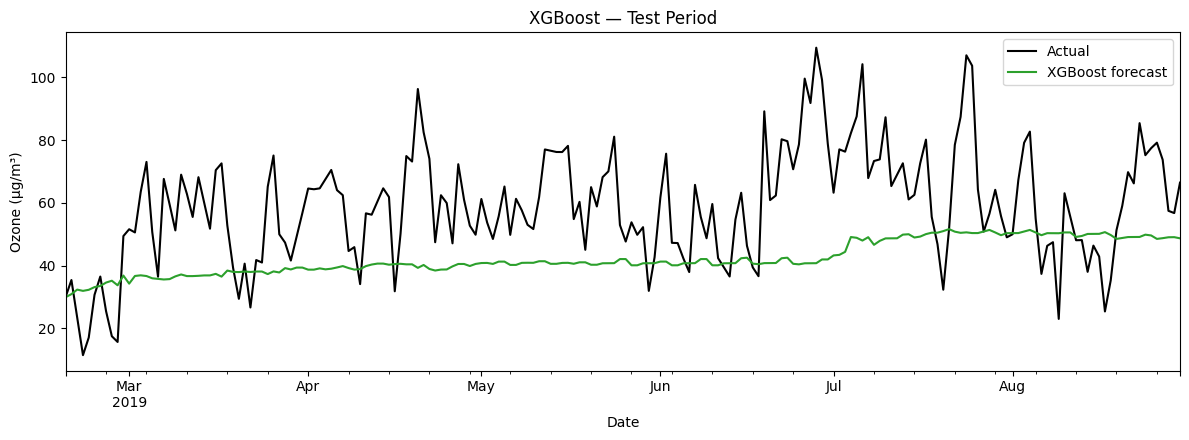

In [17]:
X_trainval, y_trainval = split_xy(trainval.index)

xgb_final_model = XGBRegressor(
    n_estimators=best_iteration, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
xgb_final_model.fit(X_trainval, y_trainval)

xgb_test_pred = recursive_forecast(xgb_final_model, trainval, test.index)
test_preds["XGBoost"] = xgb_test_pred
test_results["XGBoost"] = forecast_metrics(test, xgb_test_pred)

fig, ax = plt.subplots()
test.plot(ax=ax, label="Actual", color="black")
xgb_test_pred.plot(ax=ax, label="XGBoost forecast", color="tab:green")
ax.set_title("XGBoost — Test Period")
ax.set_ylabel("Ozone (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

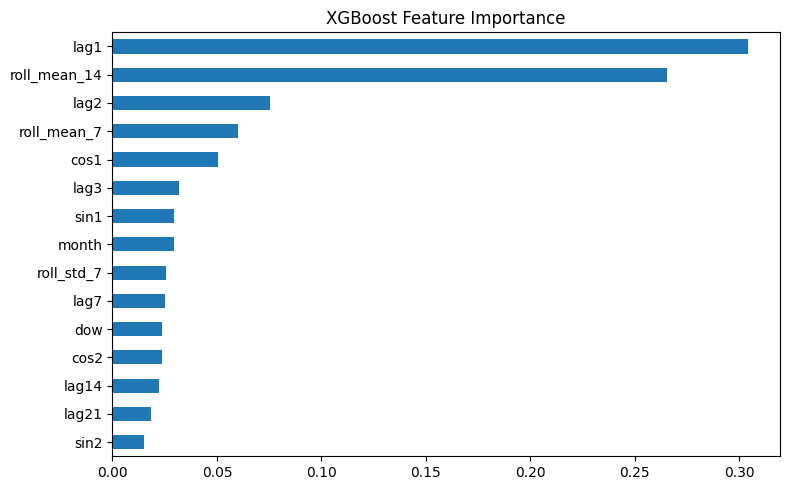

In [18]:
importances = pd.Series(xgb_final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="tab:blue")
ax.invert_yaxis()
ax.set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

**Evaluation (XGBoost):**

In [19]:
show_metrics("XGBoost")

,MAE,RMSE,MAPE (%)
Validation,13.710073,17.114767,101.556366
Test,19.352194,23.791814,31.743642


## 12. Model Comparison & Evaluation

All four models side by side on both validation and test. Note that MAPE is unstable whenever actual ozone is near zero — several winter days in the validation period have values close to 0 µg/m³, so MAPE spikes there even for accurate forecasts in absolute terms; MAE and RMSE are the more reliable metrics for this dataset.

In [20]:
model_order = ["Naive", "Seasonal Naive (7d)", "SARIMA", "XGBoost"]

print("Validation set")
display(pd.DataFrame(val_results).T.loc[model_order].sort_values("RMSE"))

print("\nTest set")
display(pd.DataFrame(test_results).T.loc[model_order].sort_values("RMSE"))

Validation set


,MAE,RMSE,MAPE (%)
SARIMA,12.911921,15.859842,95.585307
XGBoost,13.710073,17.114767,101.556366
Seasonal Naive (7d),56.760938,62.761230,436.324826
Naive,75.184906,76.947864,531.607297



Test set


,MAE,RMSE,MAPE (%)
SARIMA,14.378972,17.565032,29.465468
XGBoost,19.352194,23.791814,31.743642
Naive,29.322367,33.624209,46.624593
Seasonal Naive (7d),38.929172,43.328137,62.632491


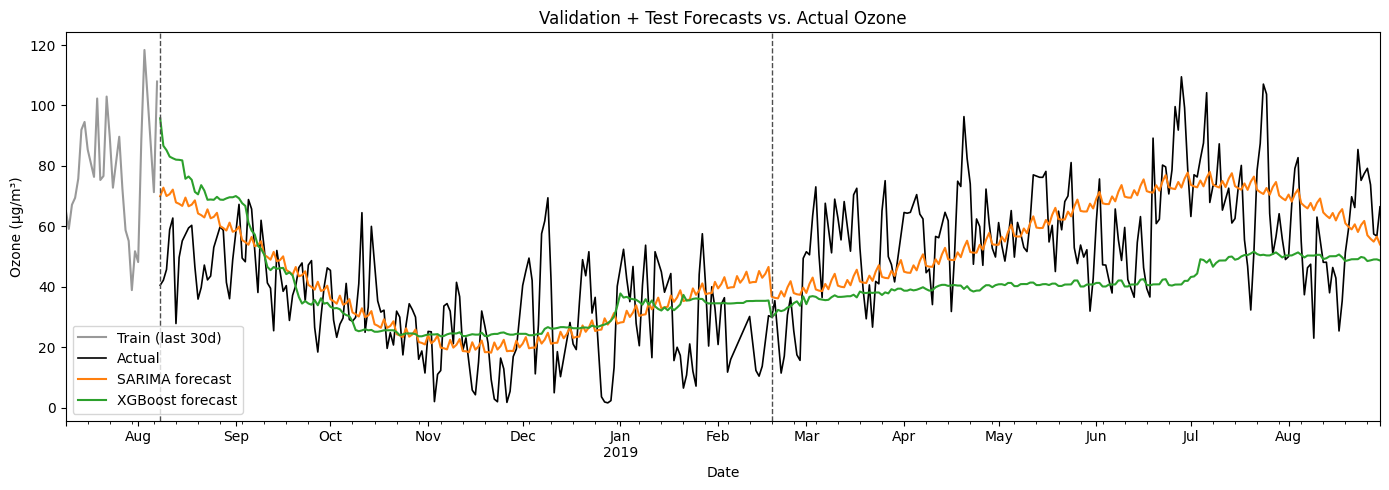

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
train.iloc[-30:].plot(ax=ax, label="Train (last 30d)", color="0.6")
pd.concat([val, test]).plot(ax=ax, label="Actual", color="black", lw=1.2)
pd.concat([val_preds["SARIMA"], test_preds["SARIMA"]]).plot(ax=ax, label="SARIMA forecast", color="tab:orange")
pd.concat([val_preds["XGBoost"], test_preds["XGBoost"]]).plot(ax=ax, label="XGBoost forecast", color="tab:green")
ax.axvline(val.index.min(), color="0.3", ls="--", lw=1)
ax.axvline(test.index.min(), color="0.3", ls="--", lw=1)
ax.set_title("Validation + Test Forecasts vs. Actual Ozone")
ax.set_ylabel("Ozone (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Conclusion

- Both SARIMA and XGBoost clearly outperform the naive and seasonal-naive baselines on both validation and test, confirming that the trend and seasonal structure identified in the STL decomposition is genuinely learnable and useful for forecasting.
- SARIMA (weekly seasonal term + Fourier terms for the annual cycle) achieved the best test-set RMSE/MAE of the models tried. XGBoost (lag/rolling/calendar features, recursive forecasting) was competitive on validation but generalized slightly less well to the test period.
- SARIMA's forecast is a smooth curve dominated by the seasonal/trend signal; XGBoost tracks a bit more local structure, but both largely miss the sharp day-to-day swings in the actual series.
- Using a held-out validation set (rather than in-sample AIC or default hyperparameters) to choose the SARIMA order and the XGBoost boosting-round count made model selection genuinely out-of-sample, and the subsequent test-set evaluation — touched only once, after all choices were locked in — gives an honest estimate of how each model would perform on truly new data.
- The residual component from the STL decomposition, and the gap between every model's error and zero, point to the same limitation: **daily ozone is heavily driven by short-term weather** (temperature, wind, sunlight, precipitation), none of which is available as a predictor in this dataset. Incorporating weather covariates would likely be the single biggest lever for improving forecast accuracy further.
- A secondary limitation is data completeness: roughly a quarter of calendar days in 2017–2019 were missing and had to be interpolated, including two multi-month sensor outages, both of which fall entirely within the training period and do not contaminate the validation or test sets.